# CBE423 Assignment 4
Kevin Park

---
## 1

1) I chose the catalyst application area on pages 5-7, which focuses on the study of catalytic materials and underlying reaction mechanisms. Typically DFT and empirical methods have drawbacks (mostly speed and accuracy) which prevent fast analysis of potential catalysts.
2) MACE-MP-0 was used to predict Potential-pH Pourbaix diagrams for solid materials. The resultant diagrams were shown to agree with explicit, more computationally intense DFT calculations.
3) Potential-pH Pourbaix diagrams depict the aqueous stability of solid materials in an electrochemical environments, making them important in assessing the viability of different materials as catalysts. Being able to assess this stability with an MLIP speeds up assessment of materials dramatically in comparison to DFT, which is more computationally expensive and slow.
4) The authors mention that while MACE-MP-0 largely shows good results when compared to DFT, it diverges in specific cases; for example, it fails to capture a stable phase of $\text{Cu}_2\text{O}$. Thus further work can be done finetuning MACE-MP-0 from a good generalist model at assessing materials to a more accurate/specialized model.

---
## 2

### 2.1

1) The absolute energy is -1300.336 eV. 

2) 

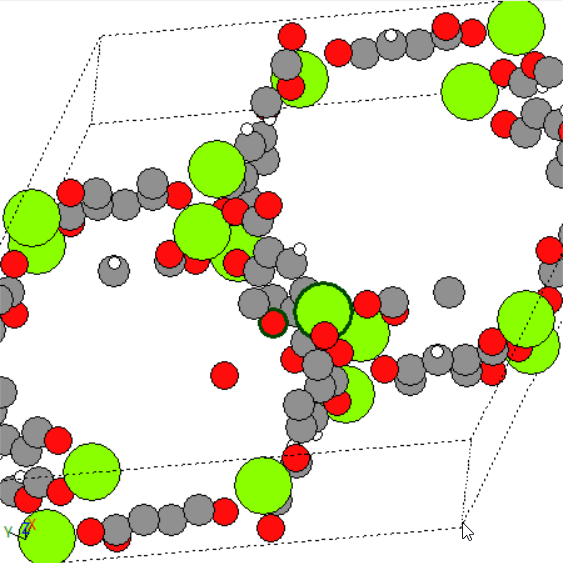

Note the other $\text{O}$ is cut off by the cell bounds but can be seen repeating at the bottom

3) The distance between the closest atom of the $\text{CO}_2$ molecule to $\text{Mg}$ is 2.229 angstroms.

In [3]:
from upet.calculator import UPETCalculator
from ase.calculators.mixing import SumCalculator
from torch_dftd.torch_dftd3_calculator import TorchDFTD3Calculator
from ase.io import read
from ase.optimize import BFGS

device = "cuda"
upet = UPETCalculator(model="pet-mad-s", version="1.5.0")
dft_d3 = TorchDFTD3Calculator(device=device, xc="r2scan", damping="bj")
calc = SumCalculator([upet, dft_d3])

mof = read("mg_mof74.cif")
mof.calc = calc
opt = BFGS(mof)
opt.run(fmax=0.01)

      Step     Time          Energy          fmax
BFGS:    0 20:45:37    -1267.365960        4.050613
BFGS:    1 20:45:38    -1272.737200        1.571166
BFGS:    2 20:45:39    -1273.614408        0.751827
BFGS:    3 20:45:40    -1274.382006        0.473227
BFGS:    4 20:45:41    -1274.526371        0.333392
BFGS:    5 20:45:42    -1274.662215        0.194875
BFGS:    6 20:45:43    -1274.692541        0.151285
BFGS:    7 20:45:44    -1274.722768        0.115816
BFGS:    8 20:45:45    -1274.742265        0.105895
BFGS:    9 20:45:46    -1274.766656        0.117505
BFGS:   10 20:45:47    -1274.782769        0.108162
BFGS:   11 20:45:48    -1274.803294        0.118490
BFGS:   12 20:45:49    -1274.823285        0.100766
BFGS:   13 20:45:50    -1274.838956        0.085799
BFGS:   14 20:45:51    -1274.849102        0.080425
BFGS:   15 20:45:52    -1274.856607        0.076889
BFGS:   16 20:45:53    -1274.865411        0.082127
BFGS:   17 20:45:54    -1274.875489        0.078277
BFGS:   18 20:

np.True_

In [5]:
# add CO2 here, save as mg_mof74_co2.cif

from ase.visualize import view

view(mof)

<Popen: returncode: None args: ['k:\\Coding Projects\\Coursework\\CBE423\\CB...>

In [6]:
# relax new adsorbate structure

from ase.io import write

mof_adsorbate = read("mg_mof74_co2.cif")
mof_adsorbate.calc = calc
opt = BFGS(mof_adsorbate)
opt.run(fmax=0.01)

write("mg_mof74_co2_relaxed.cif", mof_adsorbate)

      Step     Time          Energy          fmax
BFGS:    0 20:49:40    -1298.894832        3.994586
BFGS:    1 20:49:44    -1299.123190        3.691580
BFGS:    2 20:49:47    -1299.213414        7.624811
BFGS:    3 20:49:50    -1299.564047        1.245282
BFGS:    4 20:49:53    -1299.649969        0.762069
BFGS:    5 20:49:56    -1299.715478        1.175330
BFGS:    6 20:49:58    -1299.750149        0.658087
BFGS:    7 20:50:01    -1299.774333        0.377305
BFGS:    8 20:50:04    -1299.791254        0.473922
BFGS:    9 20:50:07    -1299.810346        0.529312
BFGS:   10 20:50:09    -1299.833765        0.429071
BFGS:   11 20:50:12    -1299.861765        0.402092
BFGS:   12 20:50:15    -1299.889966        0.379031
BFGS:   13 20:50:18    -1299.913852        0.340047
BFGS:   14 20:50:20    -1299.929851        0.344232
BFGS:   15 20:50:23    -1299.944920        0.388600
BFGS:   16 20:50:26    -1299.964475        0.349111
BFGS:   17 20:50:29    -1299.987458        0.624496
BFGS:   18 20:

In [8]:
# get results

view(mof_adsorbate) # for getting distance
abs_energy = mof_adsorbate.get_potential_energy()
print(f"Absolute energy: {abs_energy} eV")

Absolute energy: -1300.3361583188494 eV


### 2.2

An adsorption energy of -0.552 eV was predicted for the PET-MAD-XS model. Given that the experimentally reported value is 39 $\frac{\text{kJ}}{\text{mol}}$ which is roughly equal to 0.40 eV, this is fairly accurate. The sign of the results match (the paper's sign is reported as opposite) and they are within relatively close magnitudes.

In [11]:
from ase.build import molecule

co2 = molecule("CO2")
co2.calc = calc
opt = BFGS(co2)
opt.run(fmax=0.01)

co2_adsorption_energy = abs_energy - mof.get_potential_energy() - co2.get_potential_energy() 
print(f"CO2 adsorption energy: {co2_adsorption_energy} eV")

      Step     Time          Energy          fmax
BFGS:    0 21:03:28      -24.839458        1.730780
BFGS:    1 21:03:28      -24.865142        0.769756


k:\Coding Projects\Coursework\CBE423\CBE423\.venv\Lib\site-packages\metatomic\torch\ase_calculator.py:966: RuntimeWarning: invalid value encountered in scalar add
  (stress[0, 2] + stress[2, 0]) / 2.0,
k:\Coding Projects\Coursework\CBE423\CBE423\.venv\Lib\site-packages\metatomic\torch\ase_calculator.py:965: RuntimeWarning: invalid value encountered in scalar add
  (stress[1, 2] + stress[2, 1]) / 2.0,


BFGS:    2 21:03:28      -24.870364        0.074170
BFGS:    3 21:03:28      -24.870347        0.134358
BFGS:    4 21:03:28      -24.870399        0.022890
BFGS:    5 21:03:28      -24.870403        0.008176
CO2 adsorption energy: -0.5517246829511073 eV
